<a href="https://colab.research.google.com/github/mwaikelvin2k-creator/Financial_risk_analysis/blob/main/financial_loan_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [ ]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# EDA Code Here - Create New Cells As Needed
# Load the data
df = pd.read_csv("financial_loan_data.csv", encoding= "utf-8")
df

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,44,"$30,180.00",587,Employed,High School,19,24521,36,Married,3,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,56,"$49,246.00",567,Employed,Associate,33,25818,36,Married,5,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,44,"$48,958.00",645,Employed,Bachelor,20,37033,72,Married,3,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,60,"$41,025.00",560,Employed,NaN,36,14760,72,NaN,3,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [ ]:
## Remove the dollar sign in AnnualIncome column and make it  a float
df["AnnualIncome"] = df["AnnualIncome"].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [ ]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

LoanApproved
0    15220
1     4780
Name: count, dtype: int64


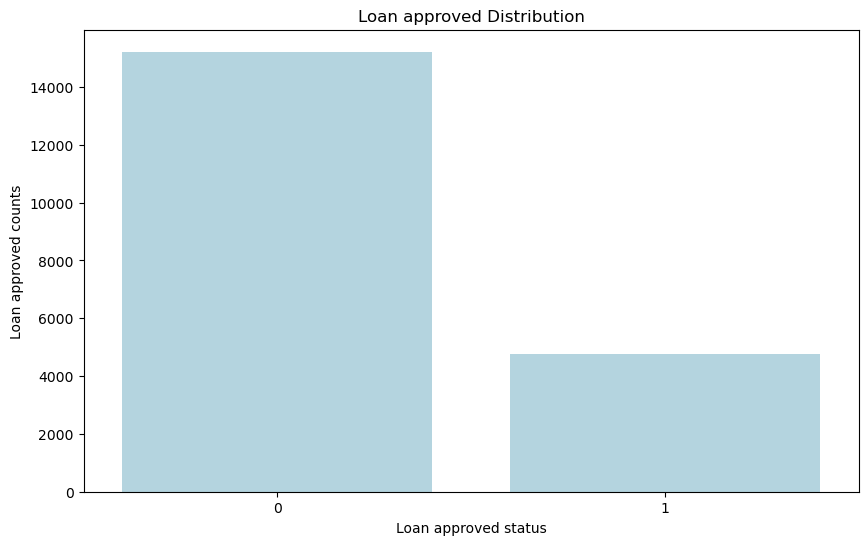

In [ ]:
## Target variable distribution
print(df["LoanApproved"].value_counts())

# Plot
plt.figure(figsize= (10,6))
sns.barplot(x=df["LoanApproved"].value_counts().index, y=df["LoanApproved"].value_counts().values, color= "lightblue")
plt.title("Loan approved Distribution")
plt.ylabel("Loan approved counts")
plt.xlabel("Loan approved status")
plt.show()


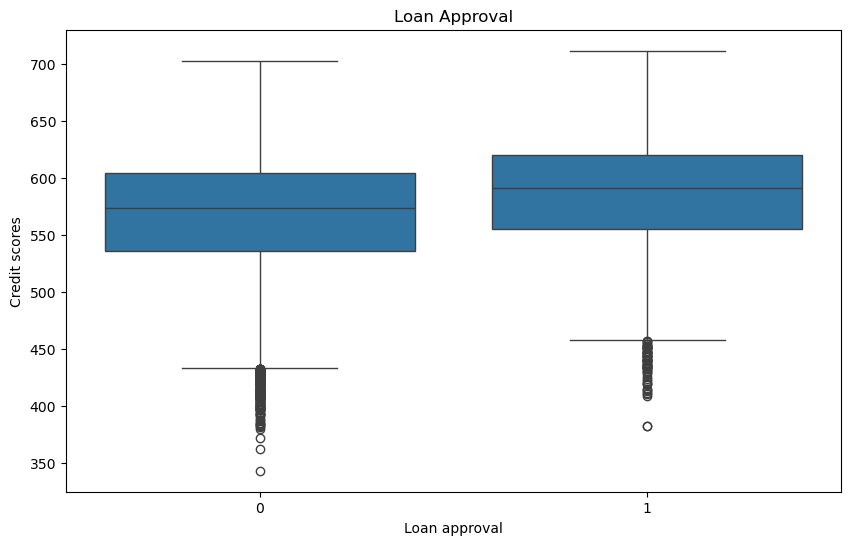

In [ ]:
plt.figure(figsize= (10,6))
sns.boxplot(x="LoanApproved", y="CreditScore", data=df)
plt.title("Loan Approval")
plt.ylabel("Credit scores")
plt.xlabel("Loan approval")
plt.show()


The plot shows CreditScore distribution for each Loan Approval group (0 = denied, 1 = approved).
Key observations:<br>

Approved (1) has a higher median credit score vs denied (0) — approved applicants tend to have better credit.<br>
Approved (1) has a tighter IQR (box is smaller), meaning scores are more consistently in the 560–625 range.<br>
Denied (0) has a wider spread and more low-score outliers going down to 340, suggesting some very poor credit scores in the denied group.<br>
There's overlap between the two boxes, meaning credit score alone doesn't fully determine approval — other factors matter too.<br>

Bottom line: Higher credit score increases approval chances, but it's not the only factor.<br>

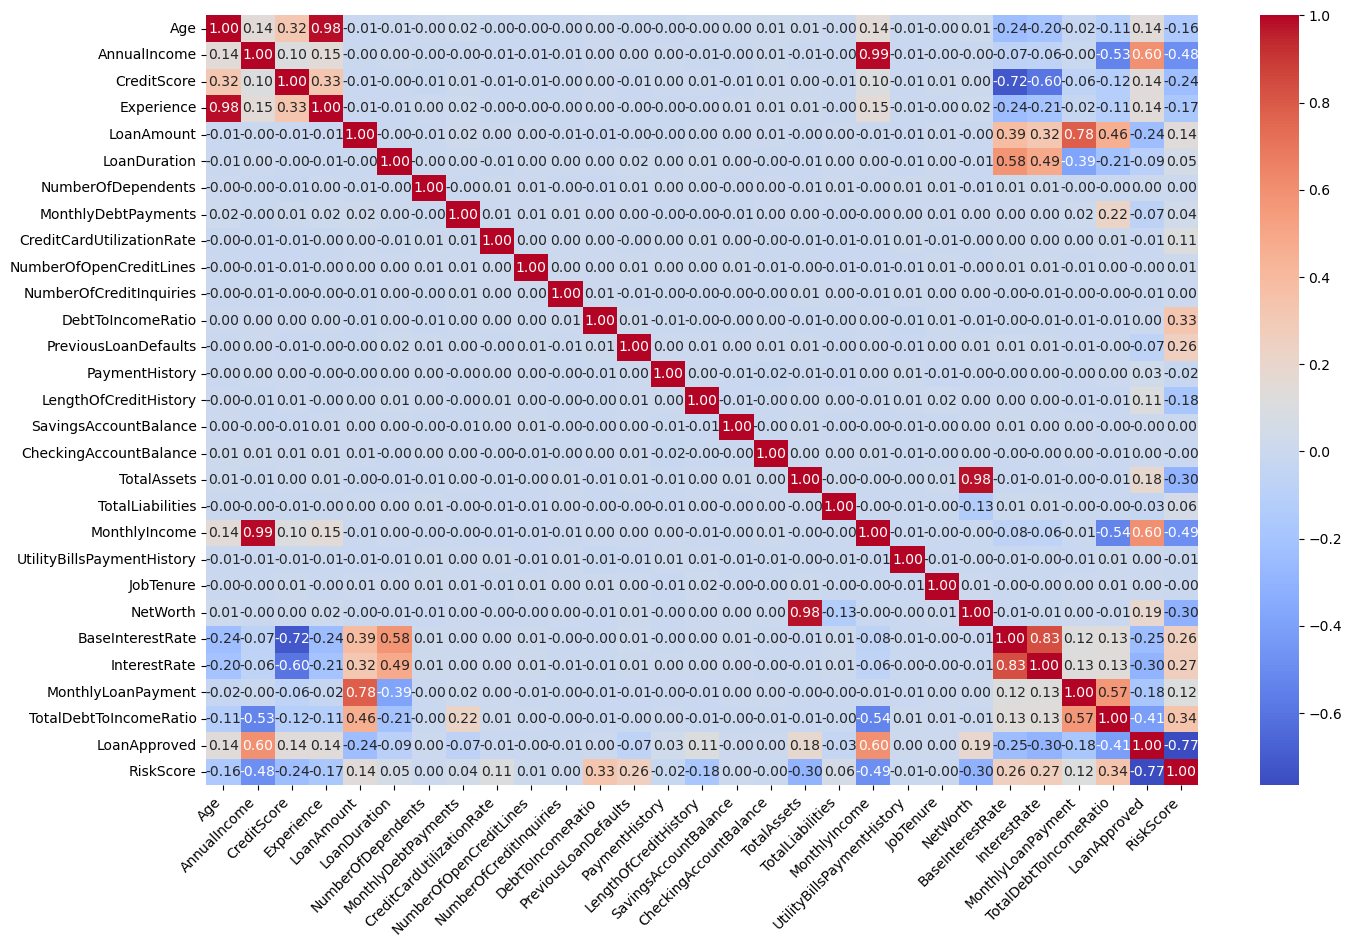

In [ ]:
# Check for correlation between the numeric features
df_numeric = df.select_dtypes(include=["int","float"])

plt.figure(figsize= (16,10))
sns.heatmap(df_numeric.corr(), annot= True, cmap= "coolwarm", fmt= ".2f")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
print(df.select_dtypes(include="object").nunique())

EmploymentStatus       3
EducationLevel         5
MaritalStatus          4
HomeOwnershipStatus    4
BankruptcyHistory      2
LoanPurpose            5
dtype: int64


From the correlation heatmap:

**Strong positive correlations (dark red):**
- Age & Experience (~0.96) — older people have more work experience, expected.
- LoanAmount & LoanDuration — bigger loans take longer to repay.

**Strong negative correlations (dark blue):**
- CreditScore & DebtToIncomeRatio — higher debt relative to income lowers your credit score.
- CreditScore & PreviousLoanDefaults — more defaults = worse credit score.

**Weak/no correlations (near 0, white):**
- Most other feature pairs, meaning they don't move together.

Age and Experience | MonthlyIncome and AnnualIncome, are highly correlated — keeping both adds redundancy hence multicollinearity.<br>
CreditScore correlations confirm it's a meaningful feature for predicting loan approval.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [ ]:
# Data Prep Code Here - Create New Cells As Needed
## Define target and features
X = df.drop(columns= ["LoanApproved"])
y = df["LoanApproved"]

## Creating a Preprocessing Pipeline
numerical_features = X.select_dtypes(include= ["int", "float"]).columns
ordinal_features = ["EducationLevel", "EmploymentStatus"]
categorical_features = X.select_dtypes(include=["object"]).columns.difference(ordinal_features)

Numerical_Transformer = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy= "median")), # for filling all missing values with the median.
    ("Scaler", StandardScaler()) # for scaling all the numerical features.

])

Categorical_Transformer = Pipeline(steps=[
    ("Encoder", OneHotEncoder(drop= "first", handle_unknown= "ignore")), # converting all categorical features to numbers.
    ("Imputer", SimpleImputer(strategy= "most_frequent"))  # for filling all missing values with the mode.
])

Ordinal_Transformer = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("Encoder", OrdinalEncoder())
])

Preprocessor = ColumnTransformer(transformers=[
    ("Nums", Numerical_Transformer, numerical_features),
    ("Cats", Categorical_Transformer, categorical_features),
    ("Ords", Ordinal_Transformer, ordinal_features)
])

### Numerical Transformer
- I used standard scaler to scale all the numeric columns around the same standard.
- I also used the simple imputer to fill all null values for numerical columns with median. I used a median to prevent the data from being skewed.

### Categorical Transformer
- I used the onehotencoder to encode - converting all string categorical columns in a machine readable format (numerals).
- I also used the simple imputer to fill missing values with the mode since they are categorical columns.

### Ordinal Transformer
- I used ordinalencoder to encode ordinal features.
- I also used the simple imputer to fill missing values with the mode since they are categorordinal columns.
### Preprocessing
- I used the column transformer to combine the numeric, categorical transformer and ordinal transformer as one to create one pipeline.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
# Split the model
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42, stratify= y)


# Base Model pipelines

Dt_pipeline= Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("Classifier",DecisionTreeClassifier(
        random_state= 42
    ))
    ])

Rf_pipeline = Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("Classifier",RandomForestClassifier(
        random_state= 42
    ))
    ])

Ab_pipeline = Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("Classifier",AdaBoostClassifier(
        random_state= 42
    ))
    ])

### 1. Decison Tree Model

In [ ]:
# Fit the model
Dt_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Confusion_matrix:
[[3023   21]
 [  24  932]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3044
           1       0.98      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.98      4000
weighted avg       0.99      0.99      0.99      4000


 AUC Score:
0.98


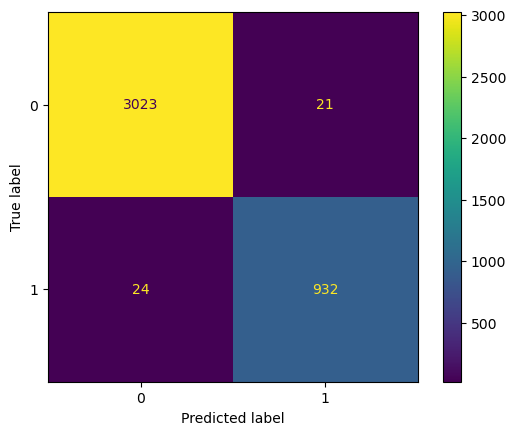

In [ ]:
# Predictions
y_preddt = Dt_pipeline.predict(X_test)
y_pred_probdt = Dt_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_preddt)
cr = classification_report(y_test, y_preddt)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probdt):.2f}")

cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()


In [ ]:
## Check for overfittting in the training data

scores = cross_val_score(Dt_pipeline, X_train,y_train, scoring= "precision")
print(f"Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

Mean: 0.9752, Std: 0.0062


#### Findings:
This model is performing exceptionally well — almost suspiciously so.<br>
Confusion Matrix:<br>

- 3023 true negatives, 932 true positives
- Only 21 false positives and 24 false negatives — very few mistakes

Metrics:<br>

- 99% across precision, recall, f1, and AUC — all classes, consistently.

Therefore I checked for overfitting using cross val score and it showed that the model was balanced with a 97% mean score with very low variance.<br>

In [ ]:
## Using Grid Search to further improve the model

dt_param_grid = {
    "Classifier__max_depth": [2, 3, 5],
    "Classifier__min_samples_split":[10, 20, 30],
    "Classifier__min_samples_leaf": [10, 20],
    "Classifier__criterion": ["gini", "entropy"],
    "Classifier__class_weight": ["balanced", None]

}

dt_grid_search = GridSearchCV(
    Dt_pipeline,
    param_grid= dt_param_grid,
    cv= 5,
    n_jobs= -1,
    scoring= "precision"

)

dt_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__class_weight': ['balanced', None], 'Classifier__criterion': ['gini', 'entropy'], 'Classifier__max_depth': [2, 3, ...], 'Classifier__min_samples_leaf': [10, 20], ...}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"


Best parameter: {'Classifier__class_weight': None, 'Classifier__criterion': 'entropy', 'Classifier__max_depth': 5, 'Classifier__min_samples_leaf': 10, 'Classifier__min_samples_split': 10}
Confusion_matrix:
[[3025   19]
 [  32  924]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3044
           1       0.98      0.97      0.97       956

    accuracy                           0.99      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.99      0.99      0.99      4000


 AUC Score:
1.00


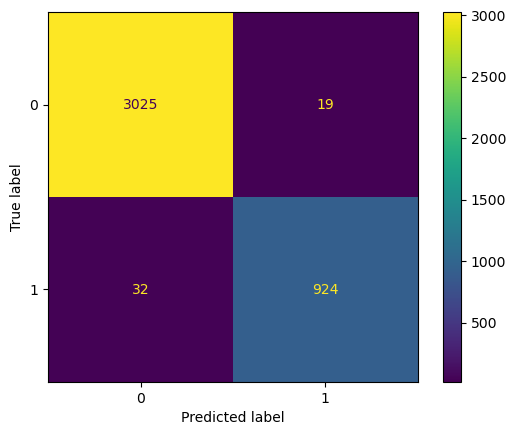

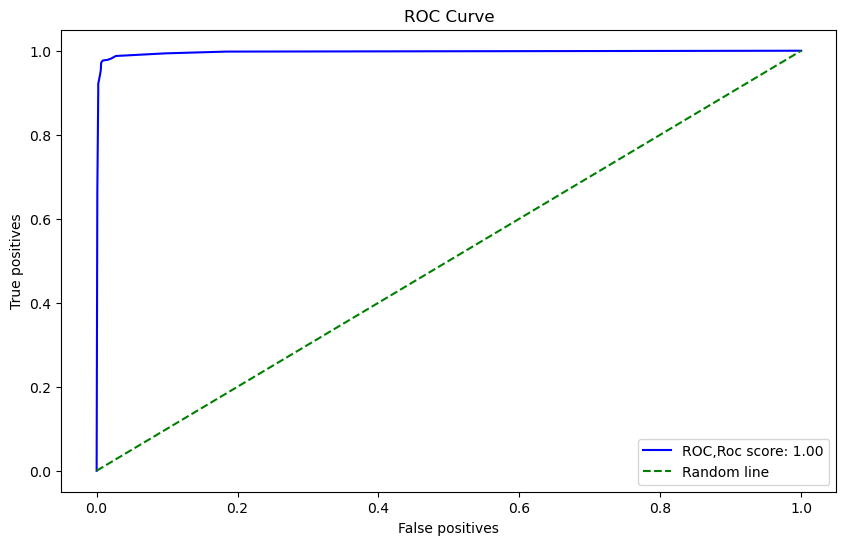

In [ ]:
# Predictions

print(f"Best parameter: {dt_grid_search.best_params_}")
dtmodel = dt_grid_search.best_estimator_
y_preddt = dtmodel.predict(X_test)
y_pred_probadt = dtmodel.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_preddt)
cr = classification_report(y_test, y_preddt)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probadt):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()

fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probadt)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_auc_score(y_test== 1, y_pred_probadt):.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()



#### Findings:
Using Grid search significantly improved the model by reducing the number of false positives from 21 to 19 while still maintaining the same level of accuracy.<br>
The score also increased from 0.99 to 1<br>
From the roc curve it is also evident that the model performs exceptionally well in predicting loan approvals.<br>

## 2. Random Forest Classifier

In [ ]:
# Fit the model
Rf_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Confusion_matrix:
[[3029   15]
 [  28  928]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.98      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000


 AUC Score:
1.00


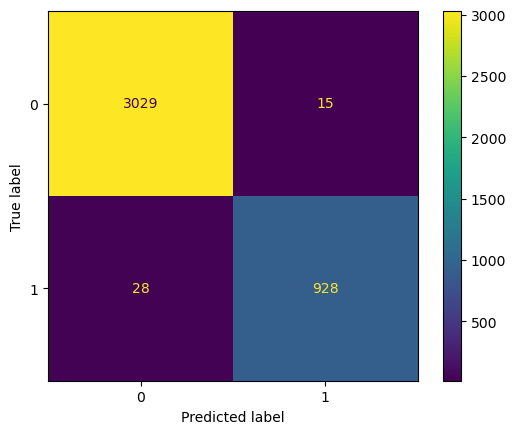

In [ ]:
# Predictions

y_predrf = Rf_pipeline.predict(X_test)
y_pred_probarf = Rf_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predrf)
cr = classification_report(y_test, y_predrf)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probarf):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()


In [ ]:
## Check for overfittting in the training data

scores = cross_val_score(Rf_pipeline, X_train,y_train, scoring= "precision")
print(f"Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

Mean: 0.9828, Std: 0.0051


#### Findings:
This model is performing exceptionally well — almost suspiciously so.<br>
Confusion Matrix:<br>

- 3029 true negatives, 928 true positives
- Only 15 false positives and 28 false negatives — very few mistakes

Metrics:<br>

- 99% across precision, recall, f1, and AUC — all classes, consistently.

Therefore I checked for overfitting using cross val score and it showed that the model was balanced with a 98% mean score with very low variance.<br>

In [ ]:
## Using Grid Search
Rf_param_grid = {
    "Classifier__n_estimators": [100, 200, 300],
    "Classifier__max_depth": [2, 3, 5],
    "Classifier__min_samples_split":[10, 20],
    "Classifier__min_samples_leaf": [10, 20],
    "Classifier__class_weight": ["balanced", None]
}

Rf_grid_search = GridSearchCV(
    Rf_pipeline,
    param_grid= Rf_param_grid,
    cv= 5,
    scoring= "precision",
    n_jobs= -1
)

Rf_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__class_weight': ['balanced', None], 'Classifier__max_depth': [2, 3, ...], 'Classifier__min_samples_leaf': [10, 20], 'Classifier__min_samples_split': [10, 20], ...}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"


Best parameter: {'Classifier__class_weight': None, 'Classifier__max_depth': 2, 'Classifier__min_samples_leaf': 10, 'Classifier__min_samples_split': 10, 'Classifier__n_estimators': 200}
Confusion_matrix:
[[3036    8]
 [ 309  647]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3044
           1       0.99      0.68      0.80       956

    accuracy                           0.92      4000
   macro avg       0.95      0.84      0.88      4000
weighted avg       0.93      0.92      0.92      4000


 AUC Score:
0.99


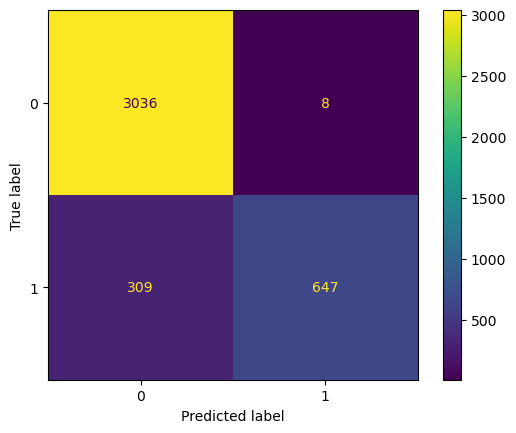

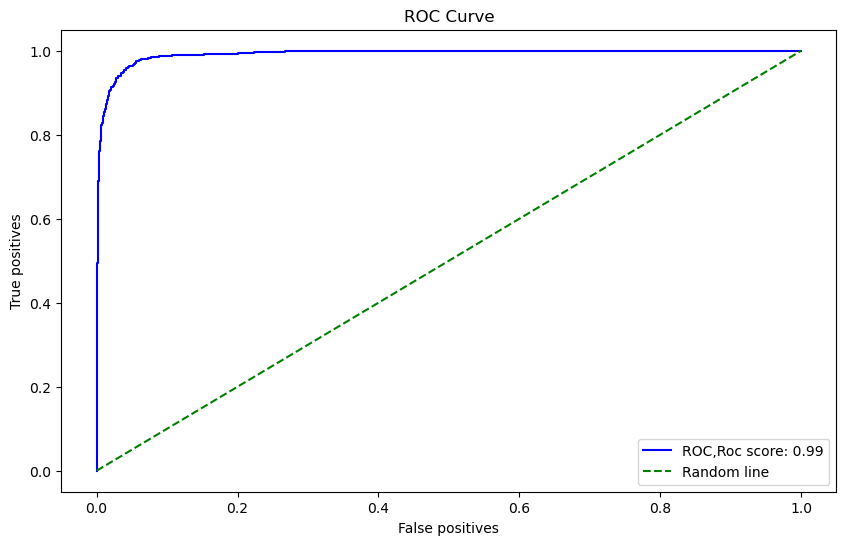

In [ ]:
# Predictions

print(f"Best parameter: {Rf_grid_search.best_params_}")
rfmodel = Rf_grid_search.best_estimator_
y_predrf = rfmodel.predict(X_test)
y_pred_probarf = rfmodel.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predrf)
cr = classification_report(y_test, y_predrf)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probarf):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()

fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probarf)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_auc_score(y_test== 1, y_pred_probarf):.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()


#### Findings:
Using Grid search significantly improved the model by reducing the number of false positives from 15 to 8 while still maintaining the same level of accuracy.<br>
However scores like recall dropped significantly.<br>
The score also dropped from 1 to 0.99<br>
From the roc curve it is also evident that the model performs exceptionally well in predicting loan approvals.<br>

## 3. AdaBoost Classifier

In [ ]:
# Fit the model
Ab_pipeline.fit(X_train, y_train)

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Confusion_matrix:
[[3038    6]
 [   4  952]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       0.99      1.00      0.99       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


 AUC Score:
1.00


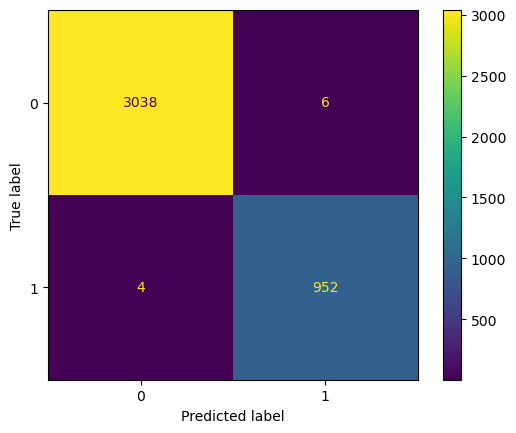

In [ ]:
## predictions

y_predab = Ab_pipeline.predict(X_test)
y_pred_probaab = Ab_pipeline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predab)
cr = classification_report(y_test, y_predab)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probaab):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()

In [ ]:
## Check for overfittting in the training data

scores = cross_val_score(Ab_pipeline, X_train,y_train, scoring= "precision")
print(f"Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

Mean: 0.9966, Std: 0.0018


#### Findings:
This model is performing exceptionally well — almost suspiciously so.<br>
Confusion Matrix:<br>

- 3038 true negatives, 952 true positives
- Only 6 false positives and 4 false negatives — very few mistakes

Metrics:<br>

- 99% across precision, recall, f1, and AUC — all classes, consistently.

Therefore I checked for overfitting using cross val score and it showed that the model was balanced with a 99% mean score with very low variance.<br>

In [ ]:
## Using Grid search

Ab_param_grid = {
    "Classifier__n_estimators": [100, 200, 300],
    "Classifier__learning_rate": [0.01, 0.1, 1]
}

ab_grid_search = GridSearchCV(
    Ab_pipeline,
    param_grid= Ab_param_grid,
    cv= 5,
    n_jobs= -1,
    scoring= "precision"
)

ab_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Classifier__learning_rate': [0.01, 0.1, ...], 'Classifier__n_estimators': [100, 200, ...]}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Nums', ...), ('Cats', ...), ...]"


Best parameter: {'Classifier__learning_rate': 1, 'Classifier__n_estimators': 200}
Confusion_matrix:
[[3043    1]
 [   0  956]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


 AUC Score:
1.00


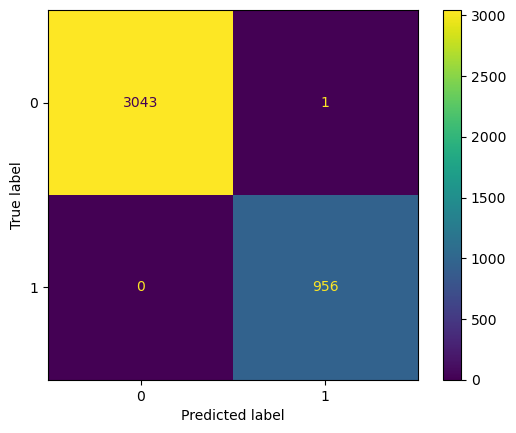

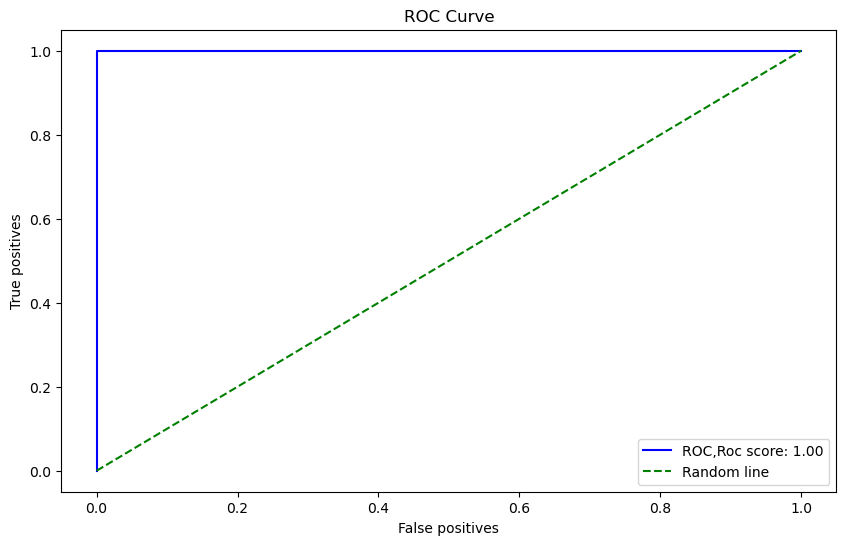

In [ ]:
# Predictions

print(f"Best parameter: {ab_grid_search.best_params_}")
abmodel = ab_grid_search.best_estimator_
y_predab = abmodel.predict(X_test)
y_pred_probaab = abmodel.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_predab)
cr = classification_report(y_test, y_predab)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_probaab):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()

fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_probaab)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_auc_score(y_test== 1, y_pred_probaab):.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()

#### Findings:
Using Grid search significantly improved the model by reducing the number of false positives from 6 to 1 while still maintaining the same level of accuracy.<br>
However scores like recall dropped significantly.<br>
The score remained the same.<br>
From the roc curve it is also evident that the model performs exceptionally well in predicting loan approvals.<br>

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### 4.Final Model

Since *Grid search* using Ada Boost classifier had the highest AUC score and had te fewest number of false positives we will use it as our final model.

Confusion_matrix:
[[3043    1]
 [   0  956]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


 AUC Score:
1.00


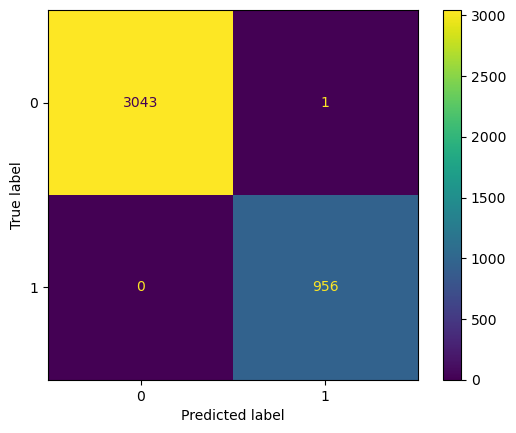

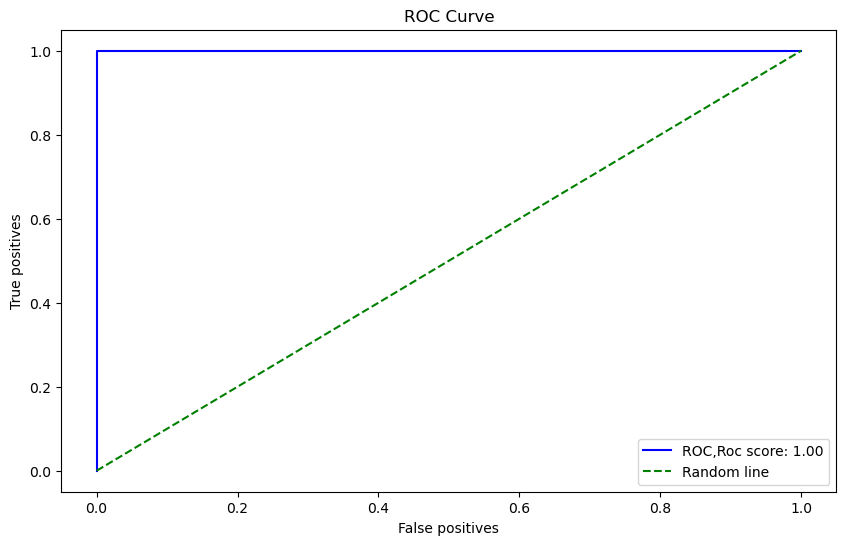

In [ ]:
Final_model = abmodel
y_pred = Final_model.predict(X_test)
y_pred_proba = Final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"Confusion_matrix:\n{cm}")
print(f"\nClassification Report:\n{cr}")
print(f"\n AUC Score:\n{roc_auc_score(y_test== 1, y_pred_proba):.2f}")

# Plotting the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix= cm)
cmd.plot()

fpr, tpr, threshold = roc_curve(y_test== 1, y_pred_proba)


## Plot roc curve
plt.figure(figsize= (10,6))
plt.plot(fpr, tpr, color= "blue", label= f"ROC,Roc score: {roc_auc_score(y_test== 1, y_pred_proba):.2f}")
plt.plot([0,1], [0,1], color= "green", linestyle= "--", label= "Random line")
plt.title("ROC Curve")
plt.xlabel("False positives")
plt.ylabel("True positives")
plt.legend()
plt.show()


In [ ]:
# Final check for data leakage
df_numeric["LoanApproved"] = y
print(df_numeric.corr()["LoanApproved"].sort_values(ascending=False))

LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate         

#### Findings
No data leakage. The highest correlation with the target is MonthlyIncome at 0.60, which is well below the 0.9 danger threshold. These are all legitimate relationships.<br>
The scores being high is genuinely justified by the data, not leakage.<br>

Key observations:<br>

MonthlyIncome and AnnualIncome (0.60, 0.60) are the strongest predictors — makes sense, income drives loan eligibility.<br>
CreditScore (0.14) is surprisingly low in linear correlation, but tree models can still extract non-linear patterns from it.<br>
Most features have near-zero correlation — the model is learning complex interactions, not a single dominant signal.<br>



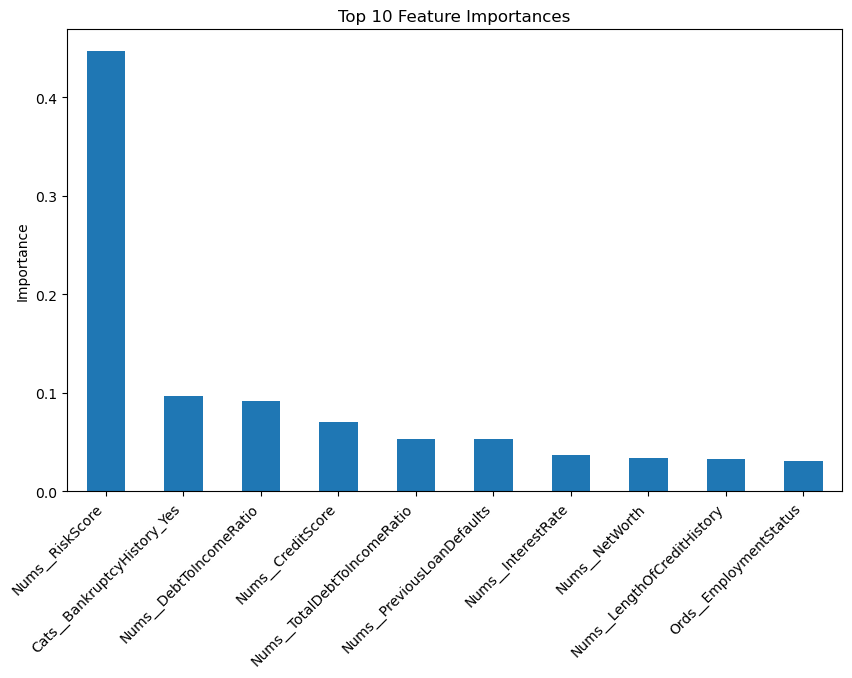

In [ ]:
## Feature Importances
feature_names = Preprocessor.get_feature_names_out()
importances = Final_model.named_steps["Classifier"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()